In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Mental Health - Analysis\data\train.csv")

print(df.shape)
print(df.info())
print(df.head())
print(df.isnull().sum())

(140700, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140700 entries, 0 to 140699
Data columns (total 20 columns):
 #   Column                                 Non-Null Count   Dtype  
---  ------                                 --------------   -----  
 0   id                                     140700 non-null  int64  
 1   Name                                   140700 non-null  object 
 2   Gender                                 140700 non-null  object 
 3   Age                                    140700 non-null  float64
 4   City                                   140700 non-null  object 
 5   Working Professional or Student        140700 non-null  object 
 6   Profession                             104070 non-null  object 
 7   Academic Pressure                      27897 non-null   float64
 8   Work Pressure                          112782 non-null  float64
 9   CGPA                                   27898 non-null   float64
 10  Study Satisfaction                     2789

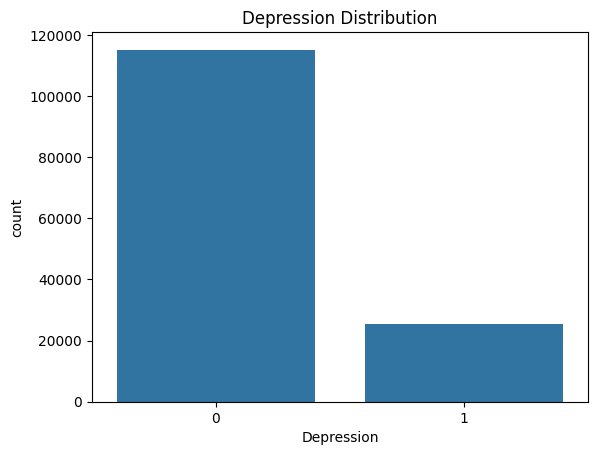

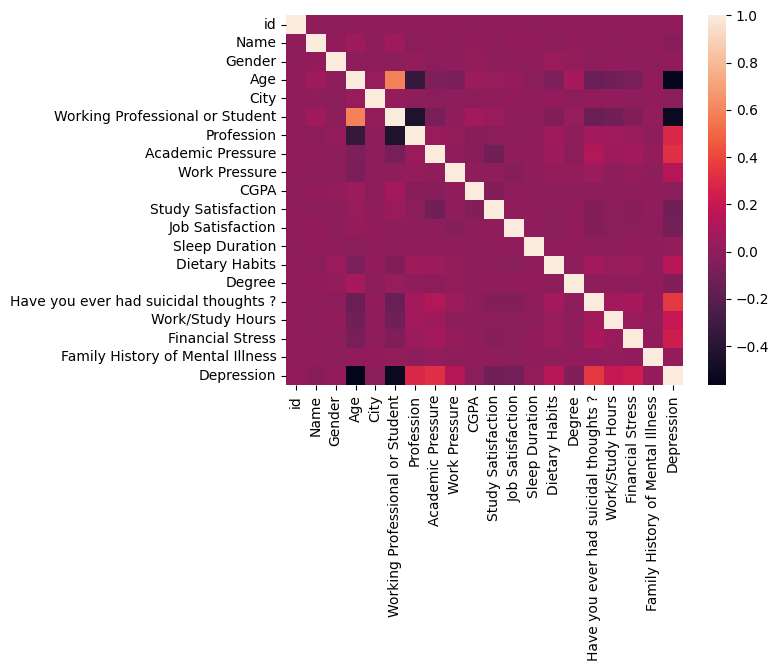

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Depression',data=df)
plt.title("Depression Distribution")
plt.show()

sns.heatmap(df.corr(numeric_only=True))
plt.show()

<Axes: xlabel='Depression', ylabel='count'>

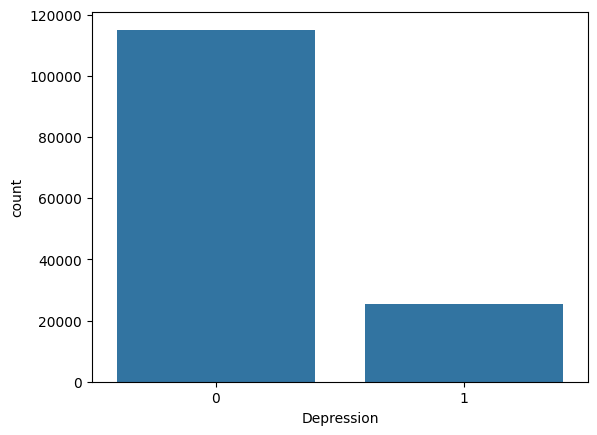

In [28]:
sns.countplot(x='Depression',data=df)

<Axes: xlabel='Gender', ylabel='count'>

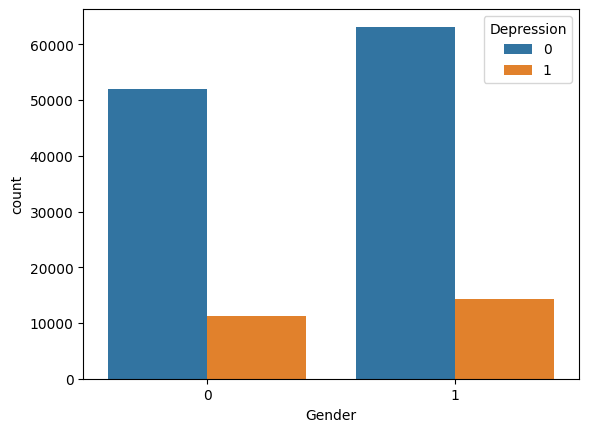

In [29]:
sns.countplot(
x='Gender',
hue='Depression',
data=df
)

<Axes: xlabel='Age', ylabel='Count'>

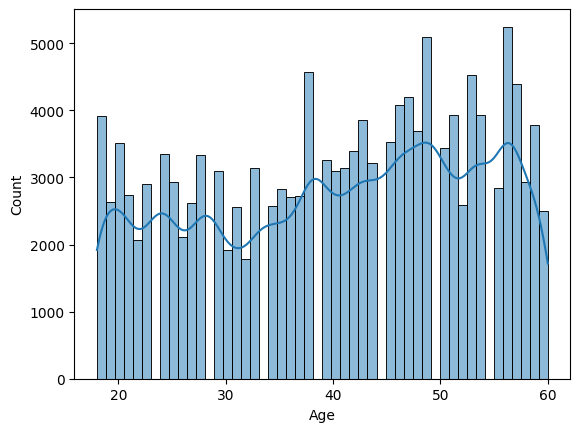

In [30]:
sns.histplot(df['Age'],kde=True)

<Axes: xlabel='Depression', ylabel='Age'>

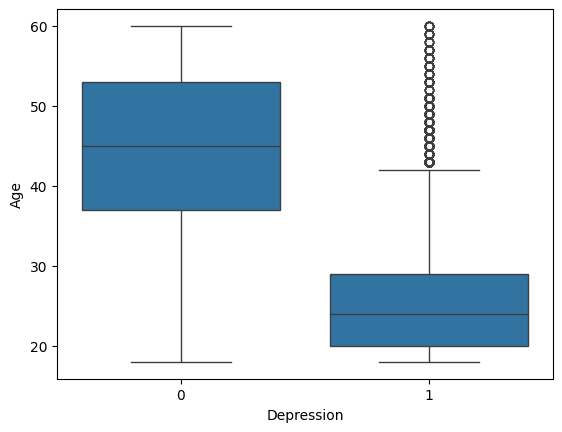

In [31]:
sns.boxplot(
x='Depression',
y='Age',
data=df
)

<Axes: xlabel='Sleep Duration'>

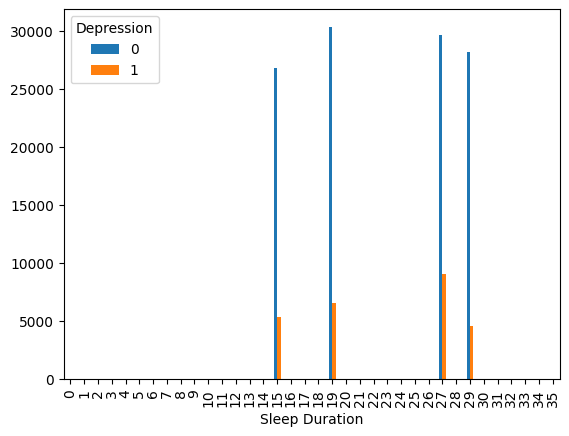

In [32]:
pd.crosstab(
df['Sleep Duration'],
df['Depression']
).plot(kind='bar')

<Axes: xlabel='Dietary Habits'>

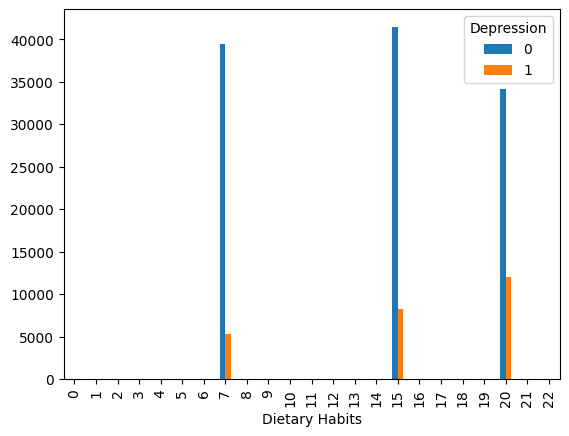

In [33]:
pd.crosstab(
df['Dietary Habits'],
df['Depression']
).plot(kind='bar')

<Axes: xlabel='Depression', ylabel='Financial Stress'>

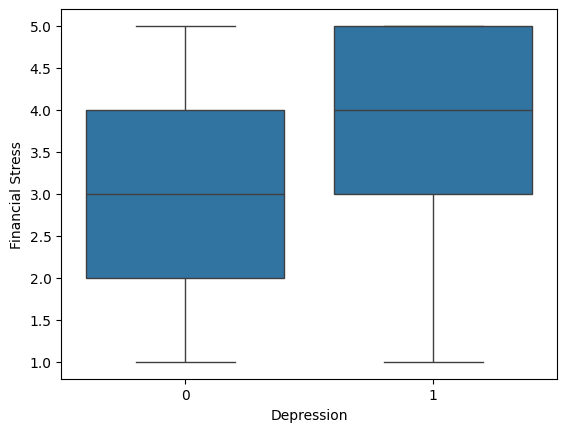

In [34]:
sns.boxplot(
x='Depression',
y='Financial Stress',
data=df
)

<Axes: xlabel='Depression', ylabel='Work Pressure'>

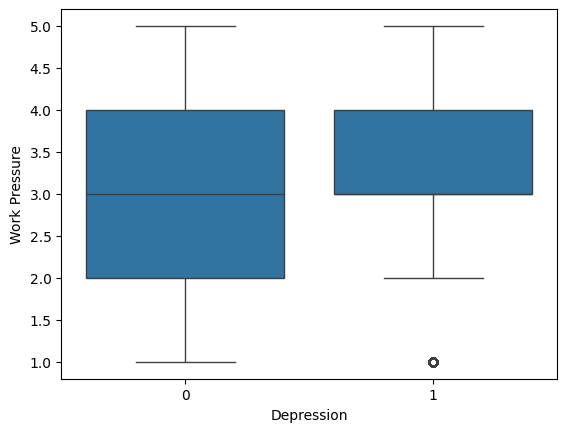

In [35]:
sns.boxplot(
x='Depression',
y='Work Pressure',
data=df
)

<Axes: xlabel='Depression', ylabel='Academic Pressure'>

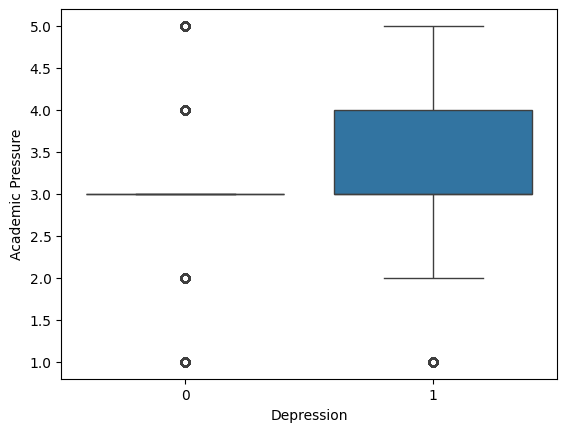

In [36]:
sns.boxplot(
x='Depression',
y='Academic Pressure',
data=df
)

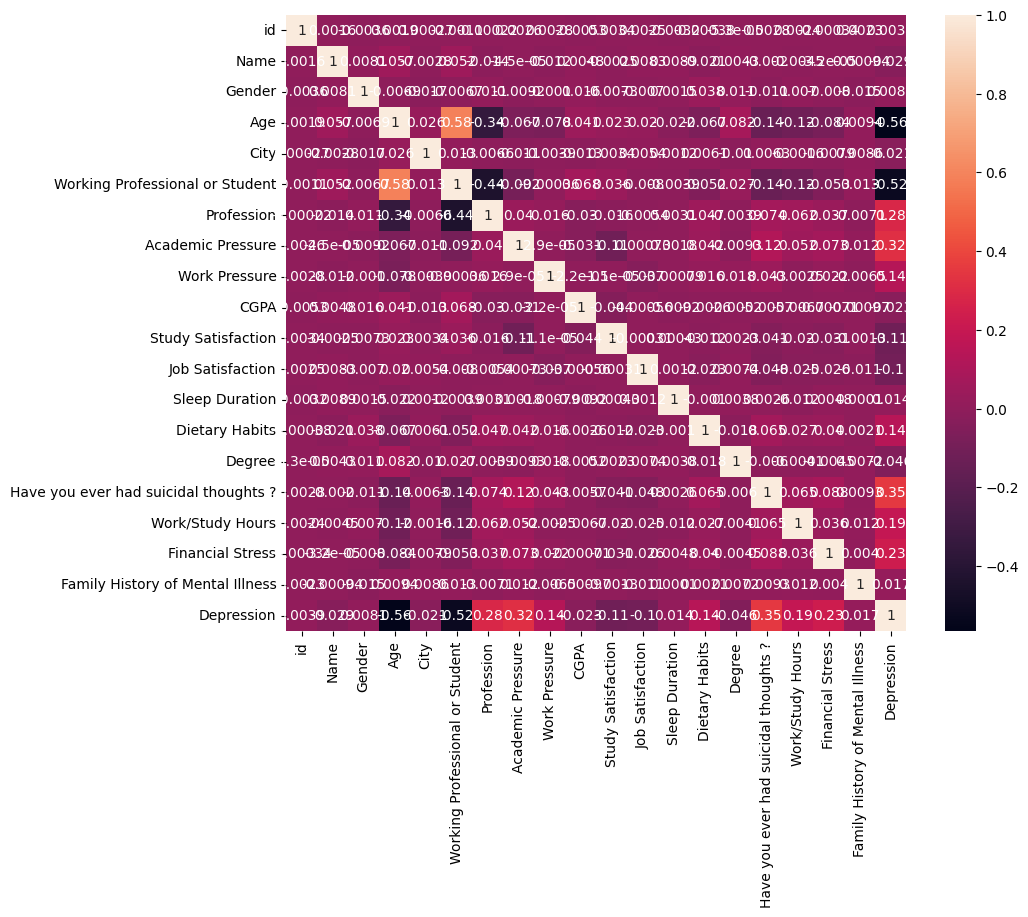

In [37]:
import seaborn as sns

corr=df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

In [38]:
df.drop(
columns=['id','Name'],
inplace=True
)

In [42]:
num_cols=df.select_dtypes(
include=['int64','float64']
).columns

for col in num_cols:
    df[col].fillna(
        df[col].median())

In [43]:
cat_cols=df.select_dtypes(
include='object'
).columns

for col in cat_cols:
    df[col].fillna(
        df[col].mode()[0])

In [44]:
from sklearn.preprocessing import LabelEncoder

encoders={}

for col in cat_cols:
    le=LabelEncoder()

    df[col]=le.fit_transform(df[col])

    encoders[col]=le

In [45]:
X=df.drop(
'Depression',
axis=1
)

y=df['Depression']

In [46]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [47]:
from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)

X_test=scaler.transform(X_test)

In [48]:
import torch
import torch.nn as nn

class DepressionNet(nn.Module):

    def __init__(self,input_size):

        super().__init__()

        self.network=nn.Sequential(

            nn.Linear(input_size,128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,32),
            nn.ReLU(),

            nn.Linear(32,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)

In [49]:
model=DepressionNet(
X_train.shape[1]
)

criterion=nn.BCELoss()

optimizer=torch.optim.Adam(
model.parameters(),
lr=0.001
)

In [50]:
X_train_tensor=torch.tensor(
X_train,
dtype=torch.float32
)

y_train_tensor=torch.tensor(
y_train.values,
dtype=torch.float32
).reshape(-1,1)

In [51]:
epochs=50

for epoch in range(epochs):

    outputs=model(
    X_train_tensor
    )

    loss=criterion(
    outputs,
    y_train_tensor
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if epoch%5==0:
        print(
        epoch,
        loss.item()
        )

0 0.6985641121864319
5 0.6455450057983398
10 0.5809494256973267
15 0.5072882175445557
20 0.4384201765060425
25 0.38245531916618347
30 0.33043426275253296
35 0.2865275740623474
40 0.2563457190990448
45 0.23513881862163544


In [52]:
from sklearn.metrics import (
accuracy_score,
precision_score,
recall_score,
f1_score,
classification_report
)

In [53]:
X_test_tensor=torch.tensor(
X_test,
dtype=torch.float32
)

pred=model(
X_test_tensor
)

pred=(pred>0.5).int()

In [54]:
print(
accuracy_score(
y_test,
pred
)
)

print(
precision_score(
y_test,
pred
)
)

print(
recall_score(
y_test,
pred
)
)

print(
f1_score(
y_test,
pred
)
)

0.9188699360341152
0.8281142857142857
0.7029491656965464
0.7604155735124357


In [55]:
import joblib

torch.save(
model.state_dict(),
'depression_model.pth'
)

joblib.dump(
scaler,
'scaler.pkl'
)

joblib.dump(
encoders,
'label_encoders.pkl'
)

['label_encoders.pkl']

In [57]:
!pip install boto3

   ---------------------------------------- 0.0/15.1 MB ? eta -:--:--
   -- ------------------------------------- 0.8/15.1 MB 6.0 MB/s eta 0:00:03
   ---- ----------------------------------- 1.6/15.1 MB 3.8 MB/s eta 0:00:04
   ----- ---------------------------------- 2.1/15.1 MB 3.2 MB/s eta 0:00:05
   ------- -------------------------------- 2.9/15.1 MB 3.6 MB/s eta 0:00:04
   ---------- ----------------------------- 3.9/15.1 MB 3.6 MB/s eta 0:00:04
   ------------ --------------------------- 4.7/15.1 MB 3.7 MB/s eta 0:00:03
   -------------- ------------------------- 5.5/15.1 MB 3.7 MB/s eta 0:00:03
   ---------------- ----------------------- 6.3/15.1 MB 3.7 MB/s eta 0:00:03
   ------------------ --------------------- 7.1/15.1 MB 3.8 MB/s eta 0:00:03
   -------------------- ------------------- 7.9/15.1 MB 3.8 MB/s eta 0:00:02
   ---------------------- ----------------- 8.7/15.1 MB 3.8 MB/s eta 0:00:02
   ------------------------- -------------- 9.7/15.1 MB 3.8 MB/s eta 0:00:02
   ---

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aiobotocore 2.25.0 requires botocore<1.40.50,>=1.40.46, but you have botocore 1.43.19 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
import boto3

print("Boto3 Version:", boto3.__version__)

Boto3 Version: 1.43.19


In [70]:
!pip install awscli


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [73]:
import joblib

feature_columns = X.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

['feature_columns.pkl']